# f0g1 flux sensitivity vs AC-Stark detuning

Workflow:
1. **Coupler map**: coupler spectroscopy vs DC flux. Fit `f_coupler(I)` so the Stark drive can track the coupler at each flux point.
2. **Stark detuning sweep**: at each detuning Delta = drive_freq - f_coupler(I), redo the f0g1-vs-flux scan with the always-on Stark drive. Drive frequency follows `f_coupler(I) + Delta` so the detuning stays constant across the flux scan. Extract df0g1/dI per Delta and plot sensitivity vs Delta.

Inner experiments are submitted as queued jobs via `CharacterizationRunner.run(coupler_current=...)` -- the worker auto-ramps `station.yoko_coupler`.

The baseline (drive-off) df0g1/dI is NOT re-measured here (we stay close to the calibrated flux). If you want a baseline reference line on the final plot, set `slope_baseline_ref` in the plot cell to a known value or leave it as `None`.

## Imports and setup

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from copy import deepcopy
from scipy.optimize import curve_fit

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base

from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

db = get_database()
config_dir = 'D:/python/multimode_expts/configs'
config_manager = ConfigVersionManager(config_dir)

client = JobClient()
health = client.health_check()
print(f"Server status: {health['status']}")
print(f"Pending jobs: {health['pending_jobs']}")

user = 'seb'
print('Welcome', user)

station = MultimodeStation(
    user=user,
    experiment_name='260423_f0g1_stark_flux_sensitivity',
)

active_reset_dict = {
    'active_reset': True,
    'ef_reset': True,
    'storage_reset': False,
    'coupler_reset': False,
    'pre_selection_reset': True,
    'man_reset': False,
    'use_qubit_man_reset': True,
    'pre_selection_parity': True,
}

USE_QUEUE = True
mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soc)

Importing all classes from  D:\python\multimode_expts\experiments\dual_rail
Importing all classes from  D:\python\multimode_expts\experiments\qsim
Importing all classes from  D:\python\multimode_expts\experiments\qubit_cavity
Importing all classes from  D:\python\multimode_expts\experiments\single_qubit
Skipped top-level files ['characterization_runner.py', 'dataset.py', 'MM_base.py', 'MM_dual_rail_base.py', 'MM_rb_base.py', 'mock_hardware.py', 'sequential_experiment.py', 'sequential_experiment_classes.py', 'station.py', 'sweep_runner.py']
Server status: healthy
Pending jobs: 0
Welcome seb
[STATION] Using main hardware_config version: CFG-HW-20260423-00003
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using main man1_storage_swap version: CFG-M1-20260420-00027
[STATION] Using main floquet_storage_swap version: CFG-FL-20260223-00023
Directory created at: D:\experiments\260423_f0g1_stark_flux_sensitivity\plots\autocalibration_2026-04-24
Data, plots, log

## Per-row Lorentzian peak fit

Used by both steps to extract the peak (coupler or f0g1) at each flux current, then linear-fit peak vs. current to get the sensitivity (MHz/mA).

In [6]:
def _lorentzian(x, A, x0, gamma, offset):
    return offset + A / (1.0 + ((x - x0) / gamma) ** 2)


def fit_peak_per_row(freqs, signal_2d, sign=1):
    """Fit a Lorentzian to each row of `signal_2d` (shape: n_rows x n_freqs).

    `sign=+1`: positive peak; `sign=-1`: negative peak (use raw avgi/avgq).
    Returns array of peak frequencies (MHz). NaN where the fit fails.
    """
    freqs = np.asarray(freqs, dtype=float)
    signal_2d = np.asarray(signal_2d, dtype=float)
    peaks = np.full(signal_2d.shape[0], np.nan)
    span = float(freqs[-1] - freqs[0])
    for i, row in enumerate(signal_2d):
        s = sign * row
        offset_guess = float(np.median(s))
        amp_guess = float(np.max(s) - offset_guess)
        x0_guess = float(freqs[int(np.argmax(s))])
        gamma_guess = max(span / 50.0, abs(freqs[1] - freqs[0]) * 2)
        try:
            popt, _ = curve_fit(
                _lorentzian, freqs, s,
                p0=[amp_guess, x0_guess, gamma_guess, offset_guess],
                maxfev=4000,
            )
            peaks[i] = popt[1]
        except Exception:
            peaks[i] = np.nan
    return peaks


def linear_sensitivity(currents_mA, peaks_MHz):
    """Linear fit: peak [MHz] vs current [mA]. Returns (slope, intercept).

    NaN-safe: skips rows where the Lorentzian fit failed.
    """
    currents_mA = np.asarray(currents_mA, dtype=float)
    peaks_MHz = np.asarray(peaks_MHz, dtype=float)
    mask = np.isfinite(peaks_MHz)
    if mask.sum() < 2:
        return np.nan, np.nan
    slope, intercept = np.polyfit(currents_mA[mask], peaks_MHz[mask], 1)
    return float(slope), float(intercept)


def plot_2d_with_peaks(freqs, currents_mA, signal_2d, peaks_MHz=None,
                       title='', cbar_label='Signal'):
    fig, ax = plt.subplots(figsize=(9, 5))
    pcm = ax.pcolormesh(freqs, currents_mA, signal_2d, shading='auto', cmap='viridis')
    if peaks_MHz is not None:
        ax.plot(peaks_MHz, currents_mA, 'r.', ms=4, label='peak fit')
        ax.legend(loc='best')
    ax.set_xlabel('Probe frequency [MHz]')
    ax.set_ylabel('Yoko-coupler current [mA]')
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax, label=cbar_label)
    plt.tight_layout()
    plt.show()
    return fig, ax

## Flux range (shared by both steps)

In [29]:
# Flux range bracketing the set point. Used by both the coupler map and the
# Stark detuning sweep so they share the same x-axis.
I_set_mA  = 0.30         # set point [mA]
I_span_mA = 0.005         # full span around set point [mA]
I_npts    = 11            # number of flux points

## Step 1 — Coupler spec vs flux current (build f_coupler(I) lookup)

Inner experiment: `meas.PulseProbeCouplerSpectroscopyExperiment`. Per-row Lorentzian fit + polynomial fit gives a callable `f_coupler(I_mA) -> MHz` used in Step 2 to keep the Stark detuning constant across the flux scan.

In [30]:
coupler_spec_defaults = AttrDict(dict(
    start=3800.0,
    step=2.0,
    expts=201,
    length=5.0,
    gain=5000,
    reps=200,
    rounds=1,
    qubits=[0],
    man_mode_no=1,
    coupler_f=False,
    prepulse=False,
    pre_sweep_pulse=None,
    active_reset=False,
))

In [31]:
def do_coupler_current_sweep(
    station,
    sweep_start=0.0,
    sweep_stop=2.0,
    sweep_npts=11,
    live_plot=True,
    safety_mA=1.0,
    **kwargs,
):
    """Coupler spec vs DC flux current, queue-based per-point loop."""
    from IPython.display import clear_output

    expt_cfg = AttrDict(deepcopy(dict(coupler_spec_defaults)))
    expt_cfg.update(kwargs)

    current_vals_mA = np.linspace(sweep_start, sweep_stop, sweep_npts)
    assert np.max(np.abs(current_vals_mA)) < safety_mA, (
        f'Requested current {np.max(np.abs(current_vals_mA)):.3f} mA exceeds '
        f'{safety_mA} mA safety.')

    runner = CharacterizationRunner(
        station=station,
        ExptClass=meas.PulseProbeCouplerSpectroscopyExperiment,
        default_expt_cfg=expt_cfg,
        job_client=client,
    )

    mother_expt = meas.PulseProbeCouplerSpectroscopyExperiment(
        soccfg=station.soc,
        path=station.data_path,
        prefix='PulseProbeCouplerSpectroscopy_coupler_current_sweep',
        config_file=station.hardware_config_file,
    )
    mother_expt.cfg = AttrDict(deepcopy(station.hardware_cfg))
    mother_expt.cfg.expt = expt_cfg
    mother_expt.data = {'coupler_current_sweep_mA': []}

    print(f'Coupler current sweep: {sweep_start} to {sweep_stop} mA ({sweep_npts} pts)')
    print(f'  File: {mother_expt.fname}')

    for idx, i_mA in enumerate(current_vals_mA):
        print(f'  [{idx+1}/{len(current_vals_mA)}] coupler current = {i_mA:.4f} mA')
        expt = runner.run(
            postprocess=False,
            coupler_current=float(i_mA * 1e-3),
        )
        mother_expt.data['coupler_current_sweep_mA'].append(i_mA)
        for key, val in expt.data.items():
            mother_expt.data.setdefault(key, []).append(val)

        if live_plot and len(mother_expt.data['coupler_current_sweep_mA']) > 1:
            clear_output(wait=True)
            plt.close('all')
            currents_so_far = np.asarray(mother_expt.data['coupler_current_sweep_mA'])
            freqs = np.asarray(mother_expt.data['xpts'][0])
            sig = np.asarray(mother_expt.data['avgi'])
            fig, ax = plt.subplots(figsize=(9, 5))
            pcm = ax.pcolormesh(freqs, currents_so_far, sig, shading='auto', cmap='viridis')
            ax.set_xlabel('Probe frequency [MHz]')
            ax.set_ylabel('Yoko-coupler current [mA]')
            ax.set_title('Coupler spectroscopy vs. DC flux (live)')
            fig.colorbar(pcm, ax=ax, label='avgi [ADC]')
            plt.tight_layout()
            plt.show()

    mother_expt.data = {k: np.array(v) for k, v in mother_expt.data.items()}
    mother_expt.save_data()
    print(f'Complete. Saved to {mother_expt.fname}')
    return mother_expt

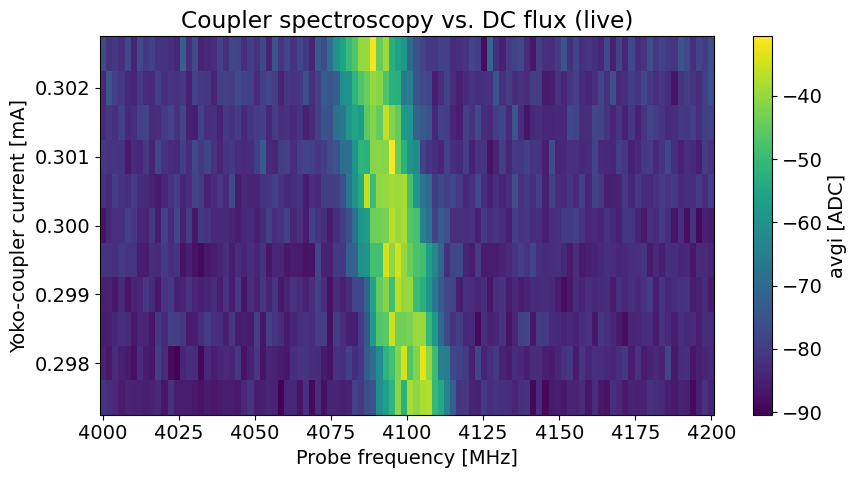

Saving D:\experiments\260423_f0g1_stark_flux_sensitivity\data\00006_PulseProbeCouplerSpectroscopy_coupler_current_sweep.h5
Complete. Saved to D:\experiments\260423_f0g1_stark_flux_sensitivity\data\00006_PulseProbeCouplerSpectroscopy_coupler_current_sweep.h5


In [32]:
coupler_f_start = 4000.0
coupler_f_stop  = 4200.0
coupler_expts   = 100
coupler_step    = (coupler_f_stop - coupler_f_start) / (coupler_expts - 1)

coupler_2d = do_coupler_current_sweep(
    station,
    sweep_start=I_set_mA - I_span_mA / 2,
    sweep_stop=I_set_mA + I_span_mA / 2,
    sweep_npts=I_npts,
    live_plot=True,
    start=coupler_f_start, step=coupler_step, expts=coupler_expts,
    gain=5000, length=5.0,
    reps=200, rounds=1,
)

Coupler polyfit (deg 2): [ 20516.4681911  -15210.45336611   6811.83120272]
f_coupler(0.300 mA) = 4095.177 MHz


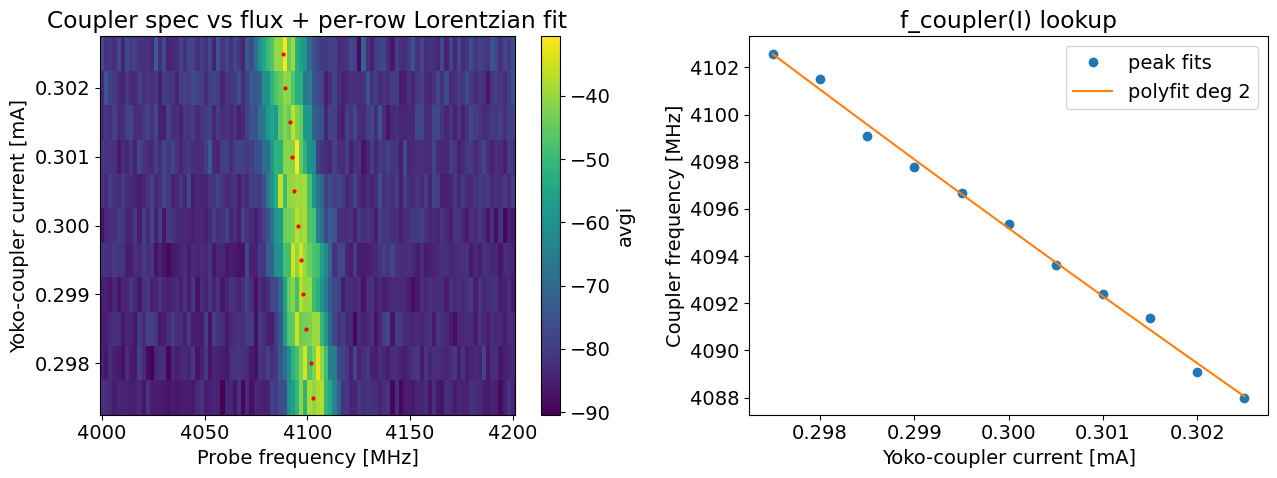

In [33]:
# Per-row Lorentzian fit -> coupler peak vs current -> polynomial f_coupler(I_mA).
COUPLER_FIT_CHANNEL = 'avgi'
COUPLER_FIT_SIGN    = 1
POLY_DEG            = 2          # 1 = linear, 2 = quadratic, etc.

coupler_currents_mA = np.asarray(coupler_2d.data['coupler_current_sweep_mA'])
coupler_freqs_MHz   = np.asarray(coupler_2d.data['xpts'][0])
coupler_sig_2d      = np.asarray(coupler_2d.data[COUPLER_FIT_CHANNEL])

coupler_peaks = fit_peak_per_row(coupler_freqs_MHz, coupler_sig_2d, sign=COUPLER_FIT_SIGN)

_mask = np.isfinite(coupler_peaks)
coupler_poly_coeffs = np.polyfit(coupler_currents_mA[_mask], coupler_peaks[_mask], POLY_DEG)
f_coupler_func = np.poly1d(coupler_poly_coeffs)

print(f'Coupler polyfit (deg {POLY_DEG}): {coupler_poly_coeffs}')
print(f'f_coupler({I_set_mA:.3f} mA) = {f_coupler_func(I_set_mA):.3f} MHz')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pcm = axes[0].pcolormesh(coupler_freqs_MHz, coupler_currents_mA, coupler_sig_2d,
                          shading='auto', cmap='viridis')
axes[0].plot(coupler_peaks, coupler_currents_mA, 'r.', ms=4)
axes[0].set_xlabel('Probe frequency [MHz]')
axes[0].set_ylabel('Yoko-coupler current [mA]')
axes[0].set_title('Coupler spec vs flux + per-row Lorentzian fit')
fig.colorbar(pcm, ax=axes[0], label=COUPLER_FIT_CHANNEL)

I_dense = np.linspace(coupler_currents_mA.min(), coupler_currents_mA.max(), 200)
axes[1].plot(coupler_currents_mA, coupler_peaks, 'o', label='peak fits')
axes[1].plot(I_dense, f_coupler_func(I_dense), '-',
             label=f'polyfit deg {POLY_DEG}')
axes[1].set_xlabel('Yoko-coupler current [mA]')
axes[1].set_ylabel('Coupler frequency [MHz]')
axes[1].set_title('f_coupler(I) lookup')
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 2 — Baseline: f0g1 spec vs flux current (no Stark drive)

Drive-off reference for df0g1/dI. Same loop pattern as Step 1 (queue-based, one
job per flux current), inner experiment is `meas.PulseProbeF0g1SpectroscopyExperiment`.
Per-row Lorentzian fit + linear fit gives `slope_baseline` which is overlaid on
the final Step 3 plot.


In [34]:
# Mirrors multiphoton qspec_defaults (same f0g1 probe conventions as multiphoton_calibration_v2).
f0g1_spec_defaults = AttrDict(dict(
    man_mode_no=1,
    start=1999,
    step=0.025,
    expts=151,
    reps=500,
    rounds=1,
    length=20.0,
    gain=100,
    pulse_type='gaussian',
    qubit_f=False,              # |f> prep comes from pre_sweep_pulse via preproc
    qubits=[0],
    transition=None,            # set to 'f0-g1' at execute time
    relax_delay=200,
    active_reset=False,
    prepulse=False,             # populated by qspec_preproc when transition is set
    pre_sweep_pulse=None,
))


def qspec_preproc(station, default_expt_cfg, **kwargs):
    """If `transition='f0-g1'` is set, builds
    `pre_sweep_pulse = prep_man_photon(photon_no=i) + pi_ge + pi_ef` so the
    qubit is in |f> before the probe. Also auto-centers `start` on the
    calibrated transition frequency if `start=None`.
    """
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    if expt_cfg.transition is not None:
        transition = expt_cfg.transition
        i = int(transition[1])
        pre_sweep_pulse = mm_base_calib.prep_man_photon(
            man_no=expt_cfg.man_mode_no, photon_no=i)
        pre_sweep_pulse.append(['multiphoton', f'g{i}-e{i}', 'pi', 0])
        pre_sweep_pulse.append(['multiphoton', f'e{i}-f{i}', 'pi', 0])
        expt_cfg.pre_sweep_pulse = mm_base_calib.get_prepulse_creator(
            pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.prepulse = len(expt_cfg.pre_sweep_pulse) > 0
        expt_cfg._transition_key = transition[0] + 'n' + '-' + transition[3] + 'n+1'
        expt_cfg._photon_idx = i

    if expt_cfg.start is None:
        band = expt_cfg.step * expt_cfg.expts / 2
        start = station.hardware_cfg.device.multiphoton['pi'][
            expt_cfg._transition_key]['frequency'][expt_cfg._photon_idx] - band
        expt_cfg.start = start

    return expt_cfg


In [13]:
# Mirrors multiphoton qspec_defaults (same f0g1 probe conventions as multiphoton_calibration_v2).
f0g1_spec_defaults = AttrDict(dict(
    man_mode_no=1,
    start=1999,
    step=0.025,
    expts=151,
    reps=500,
    rounds=1,
    length=20.0,
    gain=100,
    pulse_type='gaussian',
    qubit_f=False,              # |f> prep comes from pre_sweep_pulse via preproc
    qubits=[0],
    transition=None,            # set to 'f0-g1' at execute time
    relax_delay=200,
    active_reset=False,
    prepulse=False,             # populated by qspec_preproc when transition is set
    pre_sweep_pulse=None,
))


def qspec_preproc(station, default_expt_cfg, **kwargs):
    """If `transition='f0-g1'` is set, builds
    `pre_sweep_pulse = prep_man_photon(photon_no=i) + pi_ge + pi_ef` so the
    qubit is in |f> before the probe. Also auto-centers `start` on the
    calibrated transition frequency if `start=None`.
    """
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    if expt_cfg.transition is not None:
        transition = expt_cfg.transition
        i = int(transition[1])
        pre_sweep_pulse = mm_base_calib.prep_man_photon(
            man_no=expt_cfg.man_mode_no, photon_no=i)
        pre_sweep_pulse.append(['multiphoton', f'g{i}-e{i}', 'pi', 0])
        pre_sweep_pulse.append(['multiphoton', f'e{i}-f{i}', 'pi', 0])
        expt_cfg.pre_sweep_pulse = mm_base_calib.get_prepulse_creator(
            pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.prepulse = len(expt_cfg.pre_sweep_pulse) > 0
        expt_cfg._transition_key = transition[0] + 'n' + '-' + transition[3] + 'n+1'
        expt_cfg._photon_idx = i

    if expt_cfg.start is None:
        band = expt_cfg.step * expt_cfg.expts / 2
        start = station.hardware_cfg.device.multiphoton['pi'][
            expt_cfg._transition_key]['frequency'][expt_cfg._photon_idx] - band
        expt_cfg.start = start

    return expt_cfg


In [14]:
def do_f0g1_current_sweep(
    station,
    sweep_start=0.25,
    sweep_stop=0.35,
    sweep_npts=11,
    live_plot=True,
    safety_mA=1.0,
    **kwargs,
):
    """Sweep Yoko-coupler current and run f0g1 spectroscopy (no Stark drive)."""
    from IPython.display import clear_output

    expt_cfg = AttrDict(deepcopy(dict(f0g1_spec_defaults)))
    expt_cfg.update(kwargs)

    current_vals_mA = np.linspace(sweep_start, sweep_stop, sweep_npts)
    assert np.max(np.abs(current_vals_mA)) < safety_mA, (
        f'Requested current {np.max(np.abs(current_vals_mA)):.3f} mA exceeds '
        f'{safety_mA} mA safety.')

    runner = CharacterizationRunner(
        station=station,
        ExptClass=meas.PulseProbeF0g1SpectroscopyExperiment,
        default_expt_cfg=expt_cfg,
        preprocessor=qspec_preproc,     # wires in |f> prep
        job_client=client,
    )

    mother_expt = meas.PulseProbeF0g1SpectroscopyExperiment(
        soccfg=station.soc,
        path=station.data_path,
        prefix='PulseProbeF0g1Spectroscopy_baseline_current_sweep',
        config_file=station.hardware_config_file,
    )
    mother_expt.cfg = AttrDict(deepcopy(station.hardware_cfg))
    mother_expt.cfg.expt = expt_cfg
    mother_expt.data = {'coupler_current_sweep_mA': []}

    print(f'Baseline f0g1 sweep: {sweep_start} to {sweep_stop} mA ({sweep_npts} pts)')
    print(f'  File: {mother_expt.fname}')

    for idx, i_mA in enumerate(current_vals_mA):
        print(f'  [{idx+1}/{len(current_vals_mA)}] coupler current = {i_mA:.4f} mA')
        expt = runner.run(postprocess=False, coupler_current=float(i_mA * 1e-3))
        mother_expt.data['coupler_current_sweep_mA'].append(i_mA)
        for key, val in expt.data.items():
            mother_expt.data.setdefault(key, []).append(val)

        if live_plot and len(mother_expt.data['coupler_current_sweep_mA']) > 1:
            clear_output(wait=True)
            plt.close('all')
            currents_so_far = np.asarray(mother_expt.data['coupler_current_sweep_mA'])
            freqs = np.asarray(mother_expt.data['xpts'][0])
            sig = np.asarray(mother_expt.data['avgi'])
            fig, ax = plt.subplots(figsize=(9, 5))
            pcm = ax.pcolormesh(freqs, currents_so_far, sig, shading='auto', cmap='viridis')
            ax.set_xlabel('Probe frequency [MHz]')
            ax.set_ylabel('Yoko-coupler current [mA]')
            ax.set_title('Baseline f0g1 spectroscopy vs. DC flux (live)')
            fig.colorbar(pcm, ax=ax, label='avgi [ADC]')
            plt.tight_layout()
            plt.show()

    mother_expt.data = {k: np.array(v) for k, v in mother_expt.data.items()}
    mother_expt.save_data()
    print(f'Complete. Saved to {mother_expt.fname}')
    return mother_expt


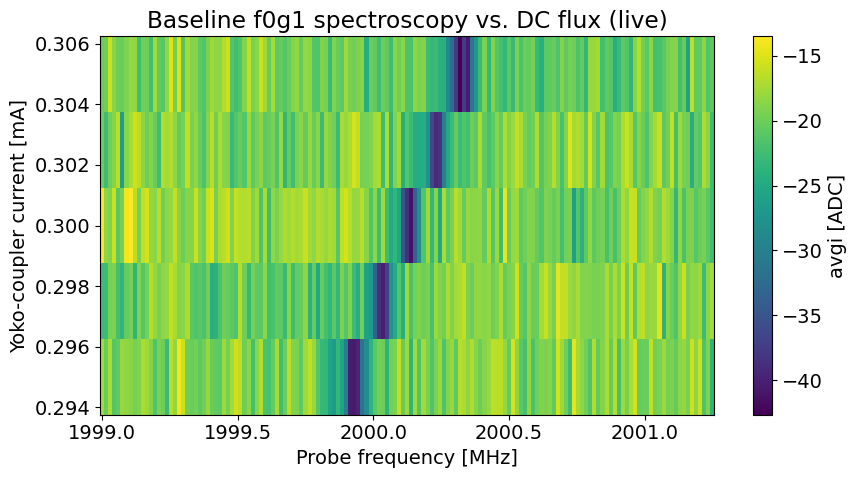

Saving D:\experiments\260423_f0g1_stark_flux_sensitivity\data\00003_PulseProbeF0g1Spectroscopy_baseline_current_sweep.h5
Complete. Saved to D:\experiments\260423_f0g1_stark_flux_sensitivity\data\00003_PulseProbeF0g1Spectroscopy_baseline_current_sweep.h5


In [16]:
f0g1_baseline = do_f0g1_current_sweep(
    station,
    sweep_start=I_set_mA - I_span_mA / 2,
    sweep_stop=I_set_mA + I_span_mA / 2,
    sweep_npts=I_npts,
    live_plot=True,
    # Inner overrides
    transition='f0-g1',
    start=1999, step=0.015, expts=151,   # start=None -> auto-center on calibrated f0g1
    gain=100, length=20.0,
    reps=500, rounds=1,
)


Baseline df0g1/dI = 39.7480 MHz/mA   (intercept 1988.206 MHz)


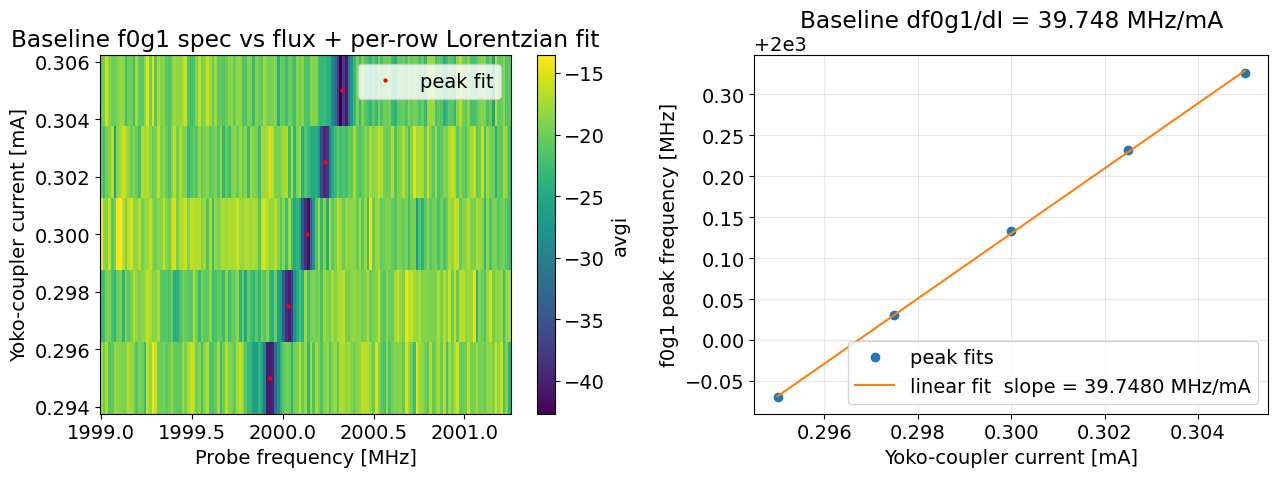

In [19]:
FIT_CHANNEL = 'avgi'   # 'avgi', 'avgq', or 'amps'
FIT_SIGN    = 1        # +1 if peak is positive, -1 if negative

baseline_currents_mA = np.asarray(f0g1_baseline.data['coupler_current_sweep_mA'])
baseline_freqs_MHz   = np.asarray(f0g1_baseline.data['xpts'][0])
baseline_sig_2d      = np.asarray(f0g1_baseline.data[FIT_CHANNEL])

peaks_baseline = fit_peak_per_row(baseline_freqs_MHz, np.abs(baseline_sig_2d), sign=FIT_SIGN)
slope_baseline, intercept_baseline = linear_sensitivity(baseline_currents_mA, peaks_baseline)

print(f'Baseline df0g1/dI = {slope_baseline:.4f} MHz/mA   (intercept {intercept_baseline:.3f} MHz)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: 2D map + per-row peak markers
pcm = axes[0].pcolormesh(baseline_freqs_MHz, baseline_currents_mA, baseline_sig_2d,
                         shading='auto', cmap='viridis')
axes[0].plot(peaks_baseline, baseline_currents_mA, 'r.', ms=4, label='peak fit')
axes[0].set_xlabel('Probe frequency [MHz]')
axes[0].set_ylabel('Yoko-coupler current [mA]')
axes[0].set_title('Baseline f0g1 spec vs flux + per-row Lorentzian fit')
axes[0].legend(loc='best')
fig.colorbar(pcm, ax=axes[0], label=FIT_CHANNEL)

# Right: peak frequency vs current + linear fit
I_dense = np.linspace(baseline_currents_mA.min(), baseline_currents_mA.max(), 200)
axes[1].plot(baseline_currents_mA, peaks_baseline, 'o', label='peak fits')
axes[1].plot(I_dense, slope_baseline * I_dense + intercept_baseline, '-',
             label=f'linear fit  slope = {slope_baseline:.4f} MHz/mA')
axes[1].set_xlabel('Yoko-coupler current [mA]')
axes[1].set_ylabel('f0g1 peak frequency [MHz]')
axes[1].set_title(f'Baseline df0g1/dI = {slope_baseline:.3f} MHz/mA')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 3 — Stark detuning sweep

For each detuning Delta:
- For each flux current I in the range set above:
  - Set `coupler_current = I*1e-3` (worker ramps the Yoko)
  - Set `drive_freq = f_coupler_func(I) + Delta` so the detuning stays constant
  - Run `meas.PulseProbeF0g1StarkAlwaysOnExperiment` (firmware freq sweep, Stark drive on)
- Per-row Lorentzian fit + linear fit → sensitivity at this Delta.

The f0g1 probe setup mirrors `multiphoton_calibration_v2.ipynb` cell 43: `qspec_preproc` builds `pre_sweep_pulse = prep_man_photon + pi_ge + pi_ef` so the qubit is in |f⟩ before the probe (otherwise there is nothing to swap and no peak shows up). Pass `transition='f0-g1'` at execute time.

In [3]:
# Mirrors multiphoton qspec_defaults + adds Stark drive fields.
f0g1_stark_defaults = AttrDict(dict(
    # f0g1 probe (same conventions as the multiphoton calibration)
    man_mode_no=1,
    start=1999,
    step=0.025,
    expts=151,
    reps=500,
    rounds=1,
    length=20.0,
    gain=100,
    pulse_type='gaussian',
    qubit_f=False,              # |f> prep comes from pre_sweep_pulse via preproc
    qubits=[0],
    transition=None,            # set to 'f0-g1' at execute time
    relax_delay=200,
    active_reset=False,
    prepulse=False,             # populated by qspec_preproc when transition is set
    pre_sweep_pulse=None,
    # Stark drive (drive_freq set per current point by the helper)
    drive_freq=4095.0,          # placeholder; overridden per point
    drive_gain=2000,
    rise_time=0.1,
    stark_guard_pre=1.0,
    stark_guard_post=1.0,
    drive_hold_margin=5.0,
))


def qspec_preproc(station, default_expt_cfg, **kwargs):
    """Copy of the multiphoton-calibration preproc.

    If `transition='f0-g1'` (or similar) is set, builds
    `pre_sweep_pulse = prep_man_photon(photon_no=i) + pi_ge + pi_ef` so the
    qubit is in |f⟩ before the probe. Also auto-centers `start` on the
    calibrated transition frequency if `start=None`.
    """
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    if expt_cfg.transition is not None:
        transition = expt_cfg.transition
        i = int(transition[1])
        pre_sweep_pulse = mm_base_calib.prep_man_photon(
            man_no=expt_cfg.man_mode_no, photon_no=i)
        pre_sweep_pulse.append(['multiphoton', f'g{i}-e{i}', 'pi', 0])
        pre_sweep_pulse.append(['multiphoton', f'e{i}-f{i}', 'pi', 0])
        expt_cfg.pre_sweep_pulse = mm_base_calib.get_prepulse_creator(
            pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.prepulse = len(expt_cfg.pre_sweep_pulse) > 0
        expt_cfg._transition_key = transition[0] + 'n' + '-' + transition[3] + 'n+1'
        expt_cfg._photon_idx = i

    if expt_cfg.start is None:
        band = expt_cfg.step * expt_cfg.expts / 2
        start = station.hardware_cfg.device.multiphoton['pi'][
            expt_cfg._transition_key]['frequency'][expt_cfg._photon_idx] - band
        expt_cfg.start = start

    return expt_cfg

In [4]:
def do_f0g1_stark_current_sweep_at_detuning(
    station,
    detuning_MHz,
    f_coupler_func,           # callable: I_mA -> f_coupler [MHz]
    sweep_start,              # mA
    sweep_stop,               # mA
    sweep_npts,
    live_plot=False,
    safety_mA=1.0,
    **kwargs,                 # override f0g1_stark_defaults
):
    """Drive-frequency-tracking f0g1 spectroscopy vs flux at fixed detuning."""
    from IPython.display import clear_output

    expt_cfg = AttrDict(deepcopy(dict(f0g1_stark_defaults)))
    expt_cfg.update(kwargs)

    current_vals_mA = np.linspace(sweep_start, sweep_stop, sweep_npts)
    assert np.max(np.abs(current_vals_mA)) < safety_mA, (
        f'Requested current {np.max(np.abs(current_vals_mA)):.3f} mA exceeds '
        f'{safety_mA} mA safety.')

    runner = CharacterizationRunner(
        station=station,
        ExptClass=meas.PulseProbeF0g1StarkAlwaysOnExperiment,
        default_expt_cfg=expt_cfg,
        preprocessor=qspec_preproc,     # wires in |f> prep + auto-center start
        job_client=client,
    )

    mother_expt = meas.PulseProbeF0g1StarkAlwaysOnExperiment(
        soccfg=station.soc,
        path=station.data_path,
        prefix=f'PulseProbeF0g1StarkAlwaysOn_det{detuning_MHz:+.2f}MHz_currentsweep',
        config_file=station.hardware_config_file,
    )
    mother_expt.cfg = AttrDict(deepcopy(station.hardware_cfg))
    mother_expt.cfg.expt = expt_cfg
    mother_expt.data = {
        'coupler_current_sweep_mA': [],
        'drive_freq_per_point': [],
        'detuning_MHz': float(detuning_MHz),
    }

    print(f'Stark detuning {detuning_MHz:+.3f} MHz: '
          f'{sweep_start} to {sweep_stop} mA ({sweep_npts} pts)')
    print(f'  File: {mother_expt.fname}')

    for idx, i_mA in enumerate(current_vals_mA):
        drive_freq = float(f_coupler_func(float(i_mA)) + detuning_MHz)
        print(f'  [{idx+1}/{len(current_vals_mA)}] I = {i_mA:.4f} mA  '
              f'drive_freq = {drive_freq:.3f} MHz')
        expt = runner.run(
            postprocess=False,
            coupler_current=float(i_mA * 1e-3),
            drive_freq=drive_freq,
        )
        mother_expt.data['coupler_current_sweep_mA'].append(i_mA)
        mother_expt.data['drive_freq_per_point'].append(drive_freq)
        for key, val in expt.data.items():
            mother_expt.data.setdefault(key, []).append(val)

        if live_plot and len(mother_expt.data['coupler_current_sweep_mA']) > 1:
            clear_output(wait=True)
            plt.close('all')
            currents_so_far = np.asarray(mother_expt.data['coupler_current_sweep_mA'])
            freqs = np.asarray(mother_expt.data['xpts'][0])
            sig = np.asarray(mother_expt.data['avgi'])
            fig, ax = plt.subplots(figsize=(9, 5))
            pcm = ax.pcolormesh(freqs, currents_so_far, sig, shading='auto', cmap='viridis')
            ax.set_xlabel('Probe frequency [MHz]')
            ax.set_ylabel('Yoko-coupler current [mA]')
            ax.set_title(f'f0g1 spec vs flux, Stark detuning {detuning_MHz:+.2f} MHz (live)')
            fig.colorbar(pcm, ax=ax, label='avgi [ADC]')
            plt.tight_layout()
            plt.show()

    mother_expt.data = {
        k: (np.array(v) if isinstance(v, list) else v)
        for k, v in mother_expt.data.items()
    }
    mother_expt.save_data()
    print(f'Complete. Saved to {mother_expt.fname}')
    return mother_expt

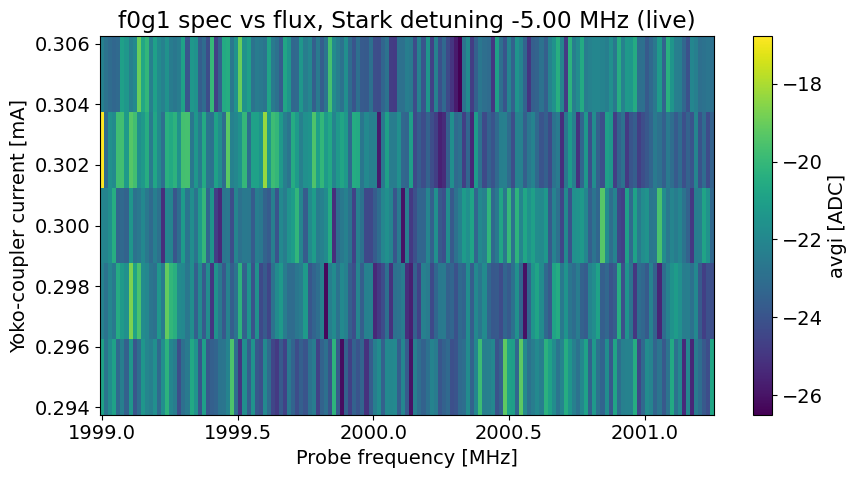

Saving D:\experiments\260423_f0g1_stark_flux_sensitivity\data\00000_PulseProbeF0g1StarkAlwaysOn_det-5.00MHz_currentsweep.h5
Complete. Saved to D:\experiments\260423_f0g1_stark_flux_sensitivity\data\00000_PulseProbeF0g1StarkAlwaysOn_det-5.00MHz_currentsweep.h5
  detuning -5.00 MHz  -> df0g1/dI = 41.4460 MHz/mA


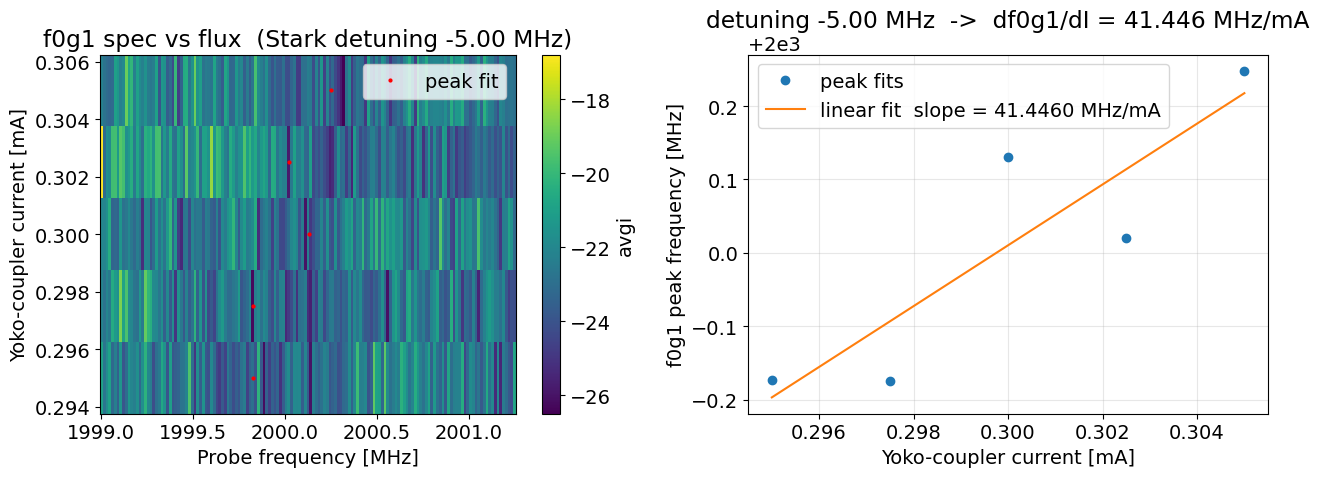

In [ ]:
# Detuning grid (MHz). Pick a span and density appropriate to your drive_gain.
detunings_MHz = np.linspace(-10, -5, 11)
f_coupler_func = np.poly1d([ 20516.4681911  -15210.45336611   6811.83120272])

# Stark drive amplitude held fixed across the whole detuning sweep.
# DRIVE_GAIN = 3000
DRIVE_GAIN = 30000
RISE_TIME  = 0.5

# f0g1 fit axis (used for per-row peak extraction below).
FIT_CHANNEL = 'avgi'
FIT_SIGN    = 1

stark_runs = []
stark_slopes = []
stark_intercepts = []

for det in detunings_MHz:
    run = do_f0g1_stark_current_sweep_at_detuning(
        station,
        detuning_MHz=float(det),
        f_coupler_func=f_coupler_func,
        sweep_start=I_set_mA - I_span_mA / 2,
        sweep_stop=I_set_mA + I_span_mA / 2,
        sweep_npts=I_npts,
        live_plot=True,
        # Inner overrides
        transition='f0-g1',
        drive_gain=DRIVE_GAIN,
        rise_time=RISE_TIME,
        start=1999, step=0.015, expts=151,
        gain=100, length=20.0,
        reps=1500, rounds=1,
    )
    stark_runs.append(run)

    currents_mA = np.asarray(run.data['coupler_current_sweep_mA'])
    freqs       = np.asarray(run.data['xpts'][0])
    sig_2d      = np.asarray(run.data[FIT_CHANNEL])
    peaks       = fit_peak_per_row(freqs, np.abs(sig_2d), sign=FIT_SIGN)
    slope, intercept = linear_sensitivity(currents_mA, peaks)
    stark_slopes.append(slope)
    stark_intercepts.append(intercept)
    print(f'  detuning {det:+.2f} MHz  -> df0g1/dI = {slope:.4f} MHz/mA')

    # Per-slice diagnostic: 2D map + peak fit + linear slope (same style as the baseline plot).
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    pcm = axes[0].pcolormesh(freqs, currents_mA, sig_2d,
                             shading='auto', cmap='viridis')
    axes[0].plot(peaks, currents_mA, 'r.', ms=4, label='peak fit')
    axes[0].set_xlabel('Probe frequency [MHz]')
    axes[0].set_ylabel('Yoko-coupler current [mA]')
    axes[0].set_title(f'f0g1 spec vs flux  (Stark detuning {det:+.2f} MHz)')
    axes[0].legend(loc='best')
    fig.colorbar(pcm, ax=axes[0], label=FIT_CHANNEL)

    I_dense = np.linspace(currents_mA.min(), currents_mA.max(), 200)
    axes[1].plot(currents_mA, peaks, 'o', label='peak fits')
    axes[1].plot(I_dense, slope * I_dense + intercept, '-',
                 label=f'linear fit  slope = {slope:.4f} MHz/mA')
    axes[1].set_xlabel('Yoko-coupler current [mA]')
    axes[1].set_ylabel('f0g1 peak frequency [MHz]')
    axes[1].set_title(f'detuning {det:+.2f} MHz  ->  df0g1/dI = {slope:.3f} MHz/mA')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

stark_slopes = np.asarray(stark_slopes)
stark_intercepts = np.asarray(stark_intercepts)


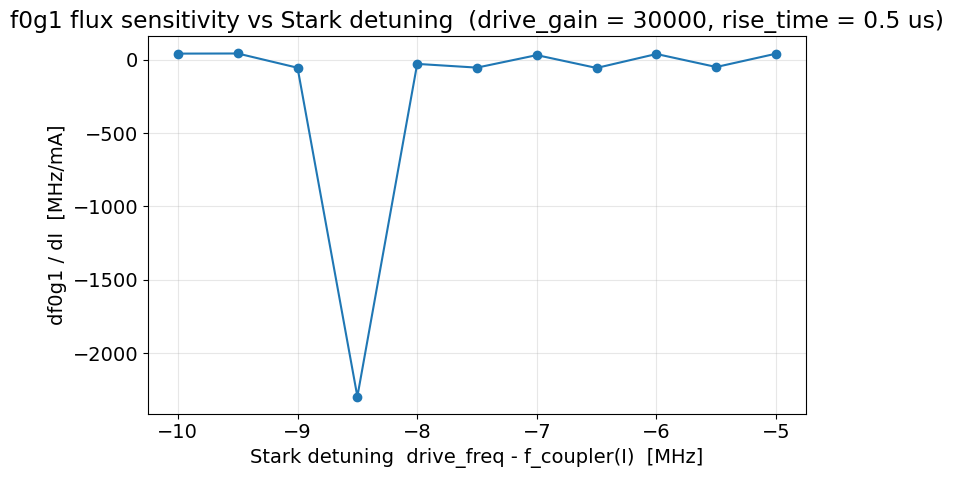

In [23]:
# Sensitivity vs detuning. If you know the drive-off baseline from elsewhere
# (e.g. multiphoton calibration), set `slope_baseline_ref` to overlay it;
# leave as None to skip.
slope_baseline_ref = None   # MHz/mA

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(detunings_MHz, stark_slopes, 'o-', label='Stark on')
if slope_baseline_ref is not None:
    ax.axhline(slope_baseline_ref, color='k', ls='--',
               label=f'baseline {slope_baseline_ref:.3f} MHz/mA')
    ax.legend()
ax.set_xlabel('Stark detuning  drive_freq - f_coupler(I)  [MHz]')
ax.set_ylabel('df0g1 / dI  [MHz/mA]')
ax.set_title(f'f0g1 flux sensitivity vs Stark detuning  '
             f'(drive_gain = {DRIVE_GAIN}, rise_time = {RISE_TIME} us)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()